# Preprocesamiento y Analisis de datos

En este capitulo, se mostraran los desarollos y hallazgos encontrados durante el ETL y EDA.

### Extraer, Transformar y Cargar (ETL)

Los datos fueron suministrados por **CARBONES COLOMBIANOS DEL CERREJON SAS**. Para cada camión, se tiene registrado cuál fue la suspensión que falló. En la tabla siguiente se detalla la información de las suspensiones de cada camión, incluyendo la fecha de montaje y desmontaje, el componente que falló y las horas en operación.

In [16]:
import pandas as pd
from tabulate import tabulate  # Para mostrar la tabla de forma bonita

# Crear el DataFrame
data = pd.DataFrame({
    "Fecha_Desmonte": ["20240411", "20240413", "20240430", "20240518", 
                        "20240616", "20240623", "20240724", "20240725", 
                        "20240804", "20240815", "20240818", "20240818", 
                        "20240824", "20240909"],
    "Fecha_Montaje": ["20240215", "20240217", "20240211", "20240113", 
                      "20240319", "20240519", "20240307", "20231222", 
                      "20240528", "20240707", "20240225", "20240714", 
                      "20231228", "20240622"],
    "No_Componente": ["02247572E", "02247810E-1", "02247881E-1", "02247824E", 
                      "02247705E-1", "02247735E-1", "02247904E", "02247786E", 
                      "02247704E-1", "02247708N", "02247746E", "02247570E-2", 
                      "02247984E", "02247721E"],
    "Cod_Comp": ["SUSP"] * 14,  
    "Mod": ["IT", "IT", "IT", "IT", "DT", "IT", "IT", "IT", "DT", "IT", 
            "DT", "IT", "IT", "IT"],
    "No_Equipo": ["0220833", "0220848", "0220740", "0220847", "0220826", 
                  "0220847", "0220849", "0220843", "0220830", "0220823", 
                  "0220836", "0220836", "0220831", "0220832"],
    "Horas": [685.77, 954.59, 998.27, 1534.82, 994.1, 473.7, 1922.72, 2907.45, 
              919.5, 454.7, 2556.31, 488.1, 3220.33, 993.1]
})

# Convertir columnas de fechas a tipo datetime
data["Fecha_Montaje"] = pd.to_datetime(data["Fecha_Montaje"], format="%Y%m%d")
data["Fecha_Desmonte"] = pd.to_datetime(data["Fecha_Desmonte"], format="%Y%m%d")

# Ordenar por Fecha_Montaje
data_ordenada = data.sort_values(by="Fecha_Montaje")

# Renombrar columnas
data_ordenada.columns = ["Fecha Desmonte", "Fecha Montaje", "No. Componente", "Comp", "Mod", "No. Equipo", "Horas"]

# Mostrar tabla en formato tabulado
print(tabulate(data_ordenada, headers='keys', tablefmt='grid'))


+----+---------------------+---------------------+------------------+--------+-------+--------------+---------+
|    | Fecha Desmonte      | Fecha Montaje       | No. Componente   | Comp   | Mod   |   No. Equipo |   Horas |
+====+=====================+=====================+==================+========+=======+==============+=========+
|  7 | 2024-07-25 00:00:00 | 2023-12-22 00:00:00 | 02247786E        | SUSP   | IT    |      0220843 | 2907.45 |
+----+---------------------+---------------------+------------------+--------+-------+--------------+---------+
| 12 | 2024-08-24 00:00:00 | 2023-12-28 00:00:00 | 02247984E        | SUSP   | IT    |      0220831 | 3220.33 |
+----+---------------------+---------------------+------------------+--------+-------+--------------+---------+
|  3 | 2024-05-18 00:00:00 | 2024-01-13 00:00:00 | 02247824E        | SUSP   | IT    |      0220847 | 1534.82 |
+----+---------------------+---------------------+------------------+--------+-------+--------------+---

Este documento presenta un análisis del comportamiento de las presiones en los camiones **Hitachi EH5000**. Se analizarán un total de *12 camiones*, cada uno de los cuales está equipado con dos suspensiones: la suspensión derecha y la suspensión izquierda trasera, sumando un total de *24 suspensiones*. A lo largo del análisis, se estudiará el comportamiento de las presiones a través del tiempo. Para ello, contamos con información adicional de dos variables relacionadas con la presión: el payload y la velocidad.

In [17]:
import os
import pandas as pd

def identify_delimiter(file_path):
    """Identifica si el archivo CSV usa coma o punto y coma como delimitador."""
    with open(file_path, 'r', encoding='utf-8') as file:
        first_line = file.readline()
        if ',' in first_line:
            return ','
        elif ';' in first_line:
            return ';'
        else:
            return None  # No se encontró un delimitador claro

# Ruta de la carpeta donde están los archivos CSV
folder_path = os.path.expanduser('/Users/user/Library/CloudStorage/OneDrive-UniversidaddelNorte/Noveno semestre/TESIS DE GRADO/Mario liñan')

# Obtener la lista de archivos CSV en la carpeta
files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".csv")]

# Identificar delimitadores para cada archivo
delimiters = {file: identify_delimiter(file) for file in files}

# Separar archivos según su delimitador
files_semicolon = [file for file, delim in delimiters.items() if delim == ';']
files_comma = [file for file, delim in delimiters.items() if delim == ',']

# Leer archivos con punto y coma como separador
df_list_semicolon = [pd.read_csv(file, sep=';', encoding='utf-8') for file in files_semicolon]

# Leer archivos con coma como separador
df_list_comma = [pd.read_csv(file, sep=',', encoding='utf-8') for file in files_comma]

# Combinar todos los dataframes
df_semicolon = pd.concat(df_list_semicolon, ignore_index=True) if df_list_semicolon else pd.DataFrame()
df_comma = pd.concat(df_list_comma, ignore_index=True) if df_list_comma else pd.DataFrame()

dfcamiones = pd.concat([df_semicolon, df_comma], ignore_index=True)

# Convertir la columna AdjustedReadTime a formato datetime si existe en el dataframe
if 'AdjustedReadTime' in dfcamiones.columns:
    dfcamiones['AdjustedReadTime'] = pd.to_datetime(dfcamiones['AdjustedReadTime'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Mostrar las primeras filas
display(dfcamiones.head(10))

,EquipmentName,AdjustedReadTime,StrutPressLeftRear,StrutPressureRightRear,PayLoad,Road Ground
0,022-740,2024-02-28 20:57:57,2760.6,3983.6,255.6,8.8
1,022-740,2024-02-28 21:00:31,3360.4,4465.9,106.5,22.0
2,022-740,2024-02-28 21:07:03,3507.9,3316.8,0.0,31.2
3,022-740,2024-02-28 21:07:55,3016.5,4278.6,0.0,26.8
4,022-740,2024-02-28 21:16:04,3596.8,3777.6,298.3,4.0
5,022-740,2024-02-28 21:17:34,3828.5,3271.9,383.5,0.0
6,022-740,2024-02-28 21:20:04,4931.3,1832.5,319.6,1.6
7,022-740,2024-02-28 21:21:34,3168.5,4067.5,225.6,3.2
8,022-740,2024-02-28 21:23:04,10255.2,8315.5,125.5,1.6
9,022-740,2024-02-28 21:25:35,15832.7,20498.5,295.9,13.3


Una vez unificado el DataFrame, procedemos al analisis de los datos para poder encontrar patrones e informacion relevante para la investigacion.

### Analisis Exploratorio de Datos (EDA)

En los siguientes codigos, observaremos el desarrollo realizado para el analisis de la base de datos correspondiente a los datos de las suspensiones. 

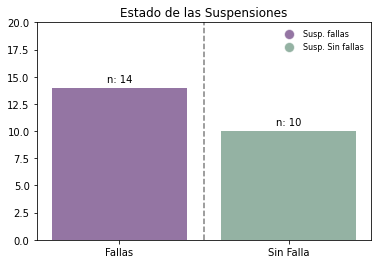

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Datos
names = ["Fallas", "Sin Falla"]
averages = [14, 10]
colors = [(0.3, 0.1, 0.4, 0.6), (0.3, 0.5, 0.4, 0.6)]

# Crear el gráfico de barras
fig, ax = plt.subplots()
bars = ax.bar(names, averages, color=colors)

# Añadir líneas de referencia
ax.axvline(x=0.5, color="grey", linestyle="--")

# Añadir texto sobre las barras
for bar, avg in zip(bars, averages):
    ax.text(bar.get_x() + bar.get_width()/2, avg + 0.5, f"n: {avg}", ha='center', fontsize=10)

# Añadir título
ax.set_title("Estado de las Suspensiones")

# Añadir leyenda
legend_labels = ["Susp. fallas", "Susp. Sin fallas"]
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markersize=10, markerfacecolor=c) for c in colors]
ax.legend(legend_patches, legend_labels, loc="upper right", fontsize=8, frameon=False)

# Mostrar el gráfico
plt.ylim(0, 20)
plt.show()

En el grafico anterior observamos la clasificacion del dataset.

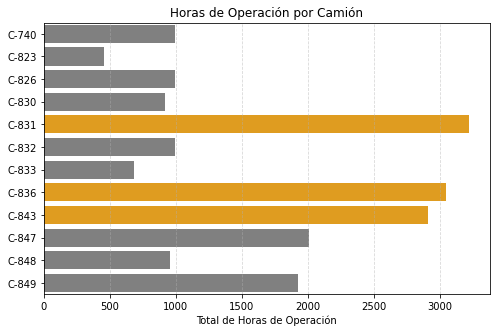

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar las horas por cada camión y ordenar de menor a mayor
data_summary = data.groupby("No_Equipo", as_index=False).agg(Total_Horas=("Horas", "sum"))
data_summary = data_summary.sort_values(by="Total_Horas")

# Cambiar "0220" por "C-"
data_summary["No_Equipo"] = data_summary["No_Equipo"].str.replace("^0220", "C-", regex=True)

# Ordenar alfabéticamente
data_summary = data_summary.sort_values(by="No_Equipo")

# Crear la columna de colores para resaltar los tres camiones con más horas
data_summary["highlight"] = np.where(data_summary["Total_Horas"].rank(method="min", ascending=False) <= 3, "orange", "grey")

# Asegurar que No_Equipo es de tipo string
data_summary["No_Equipo"] = data_summary["No_Equipo"].astype(str)

# Ordenar alfabéticamente por No_Equipo
data_summary = data_summary.sort_values(by="No_Equipo", ascending=True)

# Crear el gráfico
plt.figure(figsize=(8, 5))

sns.barplot(x="Total_Horas", y="No_Equipo", data=data_summary, palette=data_summary["highlight"].tolist())

# Ajustar título y etiquetas
plt.xlabel("Total de Horas de Operación")
plt.ylabel("")
plt.title("Horas de Operación por Camión")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

 En este grafico de barras, observamos el tiempo en operacion de cada camion, lo que nos das una idea del tiempo de operacion antes de falla de cada suspension.

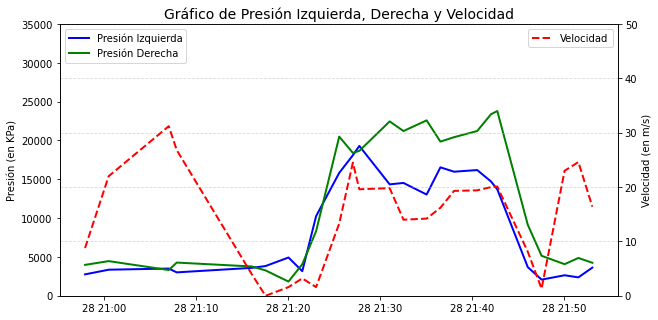

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar el camión específico
camion740 = dfcamiones[dfcamiones["EquipmentName"] == "022-740"].copy()

# Seleccionar solo los primeros 25 registros
subset_data = camion740.iloc[:25]

# Crear el gráfico
fig, ax1 = plt.subplots(figsize=(10, 5))

# Graficar la presión izquierda y derecha en el eje Y principal
ax1.plot(subset_data["AdjustedReadTime"], subset_data["StrutPressLeftRear"], 
         label="Presión Izquierda", color="blue", linewidth=2)
ax1.plot(subset_data["AdjustedReadTime"], subset_data["StrutPressureRightRear"],  
         label="Presión Derecha", color="green", linewidth=2)

# Configurar eje Y principal
ax1.set_ylabel("Presión (en KPa)")
ax1.set_ylim(0, 35000)
ax1.legend(loc="upper left")

# Crear segundo eje Y para la velocidad
ax2 = ax1.twinx()
ax2.plot(subset_data["AdjustedReadTime"], subset_data["Road Ground"],  
         label="Velocidad", color="red", linewidth=2, linestyle="dashed")

# Configurar eje Y secundario
ax2.set_ylabel("Velocidad (en m/s)")
ax2.set_ylim(0, 50)
ax2.legend(loc="upper right")

# Ajustar título y etiquetas
plt.title("Gráfico de Presión Izquierda, Derecha y Velocidad", fontsize=14)
plt.xlabel("Tiempo")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

# Mostrar el gráfico
plt.show()

Podemos ver el comportamiento de la presion de las suspensiones y la velocidad durante un ciclo de carga

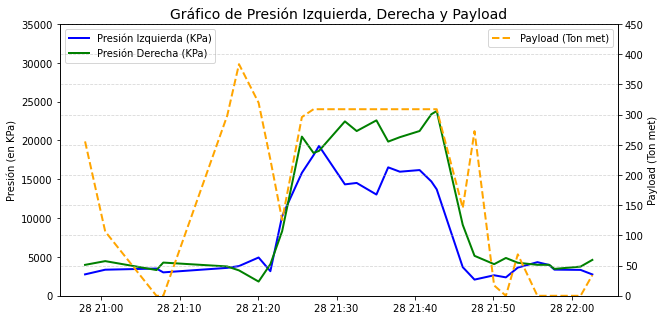

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar el camión específico
camion740 = dfcamiones[dfcamiones["EquipmentName"] == "022-740"].copy()

# Seleccionar los primeros 30 registros
subset_data = camion740.iloc[:30]

# Crear el gráfico
fig, ax1 = plt.subplots(figsize=(10, 5))

# Graficar las presiones en el eje Y principal
ax1.plot(subset_data["AdjustedReadTime"], subset_data["StrutPressLeftRear"], 
         label="Presión Izquierda (KPa)", color="blue", linewidth=2)
ax1.plot(subset_data["AdjustedReadTime"], subset_data["StrutPressureRightRear"],  
         label="Presión Derecha (KPa)", color="green", linewidth=2)

# Configurar eje Y principal (Presión)
ax1.set_ylabel("Presión (en KPa)")
ax1.set_ylim(0, 35000)
ax1.legend(loc="upper left")

# Crear segundo eje Y para el Payload
ax2 = ax1.twinx()
ax2.plot(subset_data["AdjustedReadTime"], subset_data["PayLoad"],  
         label="Payload (Ton met)", color="orange", linewidth=2, linestyle="dashed")

# Configurar eje Y secundario (Payload)
ax2.set_ylabel("Payload (Ton met)")
ax2.set_ylim(0, 450)
ax2.legend(loc="upper right")

# Ajustar título y etiquetas
plt.title("Gráfico de Presión Izquierda, Derecha y Payload", fontsize=14)
plt.xlabel("Tiempo")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

# Mostrar el gráfico
plt.show()

Observamos el comportamiento de la carga de esteril (Payload) durante el ciclo de operacion del camion. 

### Etapa de transporte

En los siguientes codigos, encontraremos ek desarrollo del analisis del comportamiento del camion durante la etapa de transporte

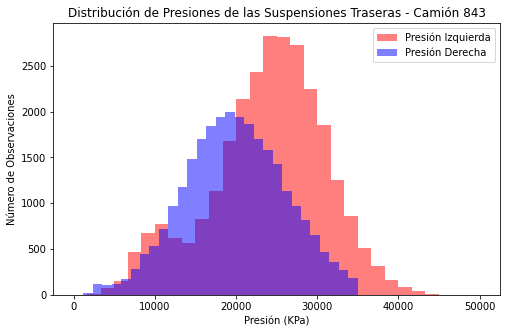

In [22]:
# Filtrar datos según las condiciones
dfcamiones2 = dfcamiones[(dfcamiones["PayLoad"] > 150) & (dfcamiones["Road Ground"] > 10)]
camion740 = dfcamiones2[dfcamiones2["EquipmentName"] == "022-843"]

# Crear el histograma
plt.figure(figsize=(8, 5))

# Histograma de la presión izquierda
plt.hist(camion740["StrutPressLeftRear"], bins=30, range=(0, 50000), color=(1, 0, 0, 0.5), label="Presión Izquierda")

# Histograma de la presión derecha (superpuesto)
plt.hist(camion740["StrutPressureRightRear"], bins=30, range=(0, 35000), color=(0, 0, 1, 0.5), label="Presión Derecha")

# Configurar etiquetas y título
plt.xlabel("Presión (KPa)")
plt.ylabel("Número de Observaciones")
plt.title("Distribución de Presiones de las Suspensiones Traseras - Camión 843")

# Agregar leyenda
plt.legend(loc="upper right")

# Mostrar el gráfico
plt.show()

Se observa mayor frecuencia de valores de presiones altos en la suspension izquierda, la cual se diagnostico con falla.

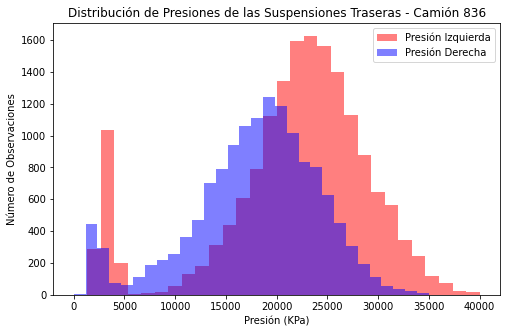

In [23]:
# Filtrar datos según las condiciones
dfcamiones2 = dfcamiones[(dfcamiones["PayLoad"] > 150) & (dfcamiones["Road Ground"] > 10)]
camion740 = dfcamiones2[dfcamiones2["EquipmentName"] == "022-836"]

# Crear el histograma
plt.figure(figsize=(8, 5))

# Histograma de la presión izquierda
plt.hist(camion740["StrutPressLeftRear"], bins=30, range=(0, 40000), color=(1, 0, 0, 0.5), label="Presión Izquierda")

# Histograma de la presión derecha (superpuesto)
plt.hist(camion740["StrutPressureRightRear"], bins=30, range=(0, 35000), color=(0, 0, 1, 0.5), label="Presión Derecha")

# Configurar etiquetas y título
plt.xlabel("Presión (KPa)")
plt.ylabel("Número de Observaciones")
plt.title("Distribución de Presiones de las Suspensiones Traseras - Camión 836")

# Agregar leyenda
plt.legend(loc="upper right")

# Mostrar el gráfico
plt.show()

En este caso, el camion 836 presente el mismo comportamiento. Sin embargo, la suspension derecha fue la que presento fallas. A continuacion, realizaremos un calculo de diferencia de medias durante la primera y segunda mitad de la operacion.

In [24]:
# Filtrar los datos según las condiciones iniciales
dfcamiones2 = dfcamiones[(dfcamiones["PayLoad"] > 150) & (dfcamiones["Road Ground"] > 10)].copy()

# Lista de camiones y suspensiones a analizar (diccionario en Python)
camiones_y_suspensiones = {
    "022-740": "StrutPressLeftRear",
    "022-826": "StrutPressureRightRear",
    "022-830": "StrutPressureRightRear",
    "022-832": "StrutPressLeftRear",
    "022-833": "StrutPressLeftRear",
    "022-836": "StrutPressureRightRear",
    "022-843": "StrutPressLeftRear",
    "022-847": "StrutPressLeftRear",
    "022-848": "StrutPressLeftRear",
    "022-849": "StrutPressLeftRear"
}

# Diccionario para almacenar los resultados
resultados = {}

# Iterar sobre cada camión y su columna de suspensión correspondiente
for camion, columna_suspension in camiones_y_suspensiones.items():
    # Filtrar los datos para el camión actual
    datos_camion = dfcamiones2[dfcamiones2["EquipmentName"] == camion]
    
    # Verificar si hay datos para el camión
    if datos_camion.empty:
        continue  # Saltar si no hay datos
    
    # Calcular el número de filas y el punto medio
    n_filas = len(datos_camion)
    punto_medio = n_filas // 2  # División entera
    
    # Calcular la media para la primera mitad
    media_primera_mitad = datos_camion[columna_suspension].iloc[:punto_medio].mean(skipna=True)
    
    # Calcular la media para la segunda mitad
    media_segunda_mitad = datos_camion[columna_suspension].iloc[punto_medio:].mean(skipna=True)
    
    # Guardar los resultados en el diccionario
    resultados[camion] = {
        "Media_Primera_Mitad": media_primera_mitad,
        "Media_Segunda_Mitad": media_segunda_mitad
    }

# Convertir los resultados a un DataFrame
df_resultados = pd.DataFrame.from_dict(resultados, orient="index").reset_index()
df_resultados.rename(columns={"index": "Camion"}, inplace=True)

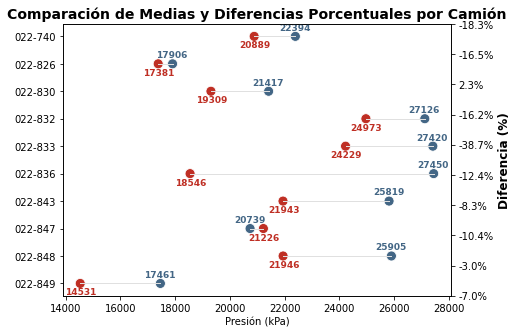

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir los resultados en un DataFrame adecuado
df_resultados = pd.DataFrame([
    {
        "Camion": camion,
        "Media_Primera_Mitad": round(res["Media_Primera_Mitad"], 0),
        "Media_Segunda_Mitad": round(res["Media_Segunda_Mitad"], 0)
    }
    for camion, res in resultados.items()
])

# Calcular la diferencia en porcentaje usando la media de ambas mitades
df_resultados["Diferencia"] = (
    (df_resultados["Media_Segunda_Mitad"] - df_resultados["Media_Primera_Mitad"]) /
    df_resultados[["Media_Primera_Mitad", "Media_Segunda_Mitad"]].mean(axis=1)
) * 100

# Transformar el DataFrame
df_resultados_long = df_resultados.melt(id_vars=["Camion", "Diferencia"], 
                                        value_vars=["Media_Primera_Mitad", "Media_Segunda_Mitad"], 
                                        var_name="Mitad", 
                                        value_name="Media")

# Asignar categorías ordenadas a los camiones para posicionamiento
df_resultados_long["Camion"] = pd.Categorical(df_resultados_long["Camion"], categories=df_resultados_long["Camion"].unique(), ordered=True)

# Colores personalizados
color_map = {"Media_Primera_Mitad": "#436685", "Media_Segunda_Mitad": "#BF2F24"}

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(8, 5))

# Convertir categorías de camión en valores numéricos
y_positions = {camion: i * 10 for i, camion in enumerate(df_resultados_long["Camion"].cat.categories)}

# Dibujar líneas entre puntos
for camion in df_resultados_long["Camion"].unique():
    datos_camion = df_resultados_long[df_resultados_long["Camion"] == camion]
    ax1.plot(datos_camion["Media"], [y_positions[camion]] * len(datos_camion), color="#E0E0E0", linewidth=1)

# Graficar puntos
sns.scatterplot(data=df_resultados_long, x="Media", y=df_resultados_long["Camion"].map(y_positions), hue="Mitad", palette=color_map, s=100, ax=ax1)

# Ajustar etiquetas
for _, row in df_resultados_long.iterrows():
    x_offset = 20 if row["Mitad"] == "Media_Segunda_Mitad" else -20  # Separación en X
    y_offset = 3.2 if row["Mitad"] == "Media_Segunda_Mitad" else -3.2  # Separación en Y

    ax1.text(row["Media"] + x_offset, y_positions[row["Camion"]] + y_offset, f"{int(row['Media'])}",
             color=color_map[row["Mitad"]], fontsize=9, ha="center", va="center", weight="bold")

# Configurar el gráfico
ax1.set_xlabel("Presión (kPa)")
ax1.set_ylabel(None)
ax1.set_title("Comparación de Medias y Diferencias Porcentuales por Camión", fontsize=14, fontweight="bold")
ax1.set_yticks(list(y_positions.values()))
ax1.set_yticklabels(y_positions.keys())  # Restaurar nombres originales de camiones
ax1.grid(False)
ax1.legend().set_visible(False)

# Crear eje secundario para diferencias porcentuales
ax2 = ax1.twinx()
ax2.set_yticks(ax1.get_yticks())
ax2.set_yticklabels([f"{round(dif, 1)}%" for dif in df_resultados["Diferencia"]])
ax2.set_ylabel("Diferencia (%)", fontsize=12, fontweight="bold", color="black")
ax2.set_frame_on(True)

# Ajustar diseño
plt.subplots_adjust(right=0.8)
plt.show()

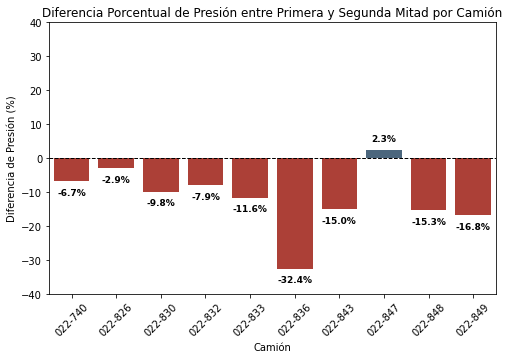

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la diferencia en porcentaje
df_resultados["Diferencia_Porcentual"] = (
    (df_resultados["Media_Segunda_Mitad"] - df_resultados["Media_Primera_Mitad"]) / df_resultados["Media_Primera_Mitad"]
) * 100

# Crear el gráfico de barras vertical con colores para positivos y negativos
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#BF2F24" if x < 0 else "#436685" for x in df_resultados["Diferencia_Porcentual"]]
sns.barplot(data=df_resultados, x="Camion", y="Diferencia_Porcentual", palette=colors, ax=ax)

# Agregar etiquetas de los valores sobre cada barra
for index, row in df_resultados.iterrows():
    y_offset = -2 if row["Diferencia_Porcentual"] < 0 else 2  # Ajuste de posición de etiqueta
    ax.text(index, row["Diferencia_Porcentual"] + y_offset, f"{row['Diferencia_Porcentual']:.1f}%", 
            ha='center', va='bottom' if row["Diferencia_Porcentual"] > 0 else 'top', 
            fontsize=9, weight="bold")

# Configurar el gráfico
ax.set_xlabel("Camión")
ax.set_ylabel("Diferencia de Presión (%)")
ax.set_title("Diferencia Porcentual de Presión entre Primera y Segunda Mitad por Camión")
ax.set_ylim(-40, 40)  # Ajustar el rango del eje Y
plt.axhline(0, color='black', linestyle='--', linewidth=1)  # Línea en el eje 0 para referencia
plt.xticks(rotation=45)
plt.show()

En esta grafica de barra, se observan las suspensiones que presentaron fallas por camion. Importante destacar que se obviaron los camiones 823 ya que no tenian datos de presion y el 831 - suspension izquierda *(Falla)* no contaba con datos.

### Velocidad vs Presion

CHM Minería tiene una hipótesis sobre las fallas de las suspensiones. La hipótesis se centra en las velocidades que registra el camión durante la etapa de transporte. El gerente de soporte tecnico menciona que en esta etapa las velocidades pueden estar afectando la suspension.

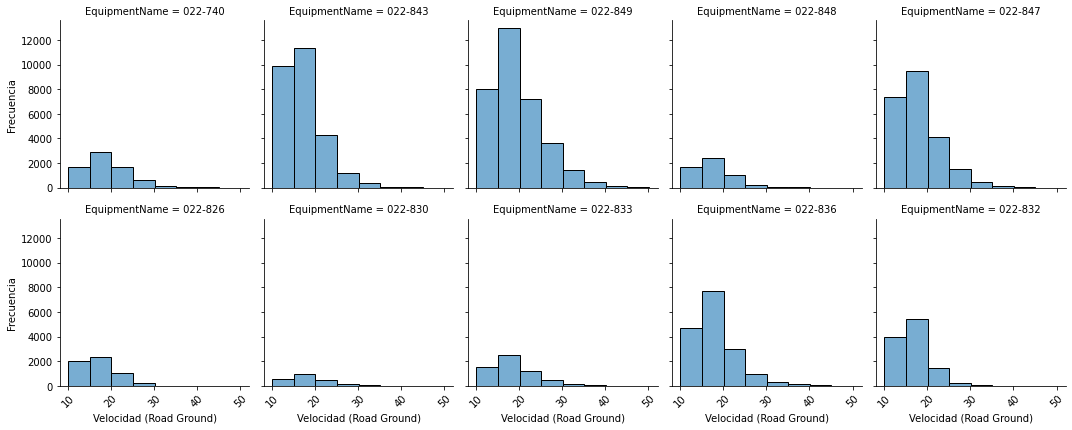

In [37]:
# Filtrar los datos para los camiones especificados
camiones = list(camiones_y_suspensiones.keys())
velocidades_camiones = dfcamiones2[dfcamiones2["EquipmentName"].isin(camiones)][["EquipmentName", "Road Ground"]]

# Crear el gráfico con FacetGrid para dividir por camión en 5 columnas
g = sns.FacetGrid(velocidades_camiones, col="EquipmentName", col_wrap=5, sharex=True, sharey=True)

# Agregar histogramas
g.map_dataframe(sns.histplot, x="Road Ground", binwidth=5, alpha=0.6, kde=False)

# Configurar etiquetas de los ejes
g.set_axis_labels("Velocidad (Road Ground)", "Frecuencia")

# Ajustar etiquetas del eje X para que sean visibles y rotadas
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), visible=True, rotation=45)

plt.show()


In [39]:
# Extraer los nombres de los camiones a analizar
camiones = list(camiones_y_suspensiones.keys())

# Crear la primera tabla: Frecuencia y porcentaje de velocidades mayores a 25 km/h por camión
tabla_frecuencias = (
    dfcamiones2[dfcamiones2["EquipmentName"].isin(camiones) & (dfcamiones2["Road Ground"] > 25)]
    .groupby("EquipmentName")
    .size()
    .reset_index(name="Frecuencia")
)

# Calcular el porcentaje
tabla_frecuencias["Porcentaje (%)"] = round((tabla_frecuencias["Frecuencia"] / tabla_frecuencias["Frecuencia"].sum()) * 100, 1)

# Crear la segunda tabla: Velocidades máximas por camión
velocidad_maxima = (
    dfcamiones2[dfcamiones2["EquipmentName"].isin(camiones)]
    .groupby("EquipmentName")["Road Ground"]
    .max()
    .reset_index(name="Velocidad Máxima")
)

# Combinar ambas tablas
tabla_combinada = pd.merge(tabla_frecuencias, velocidad_maxima, on="EquipmentName", how="left")

# Mostrar la tabla con formato tabulado
print(tabulate(tabla_combinada, headers="keys", tablefmt="pretty", showindex=False))

+---------------+------------+----------------+------------------+
| EquipmentName | Frecuencia | Porcentaje (%) | Velocidad Máxima |
+---------------+------------+----------------+------------------+
|    022-740    |    879     |      6.4       |       45.2       |
|    022-826    |    286     |      2.1       |       43.5       |
|    022-830    |    189     |      1.4       |       42.4       |
|    022-832    |    299     |      2.2       |       43.5       |
|    022-833    |    700     |      5.1       |       45.6       |
|    022-836    |    1401    |      10.2      |       45.5       |
|    022-843    |    1710    |      12.5      |       45.2       |
|    022-847    |    2136    |      15.6      |       45.4       |
|    022-848    |    344     |      2.5       |       40.6       |
|    022-849    |    5768    |      42.1      |       46.5       |
+---------------+------------+----------------+------------------+


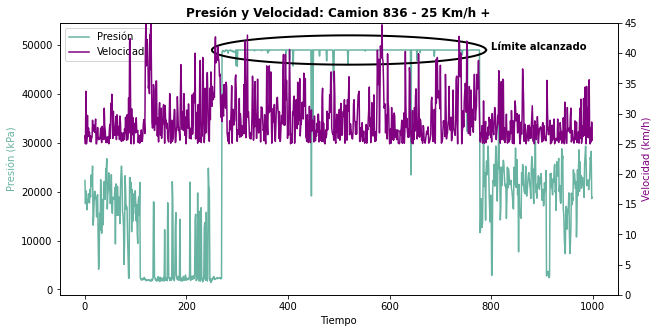

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar los datos
prueba = dfcamiones2[dfcamiones2["Road Ground"] >= 25]
data_plot = (
    prueba[prueba["EquipmentName"] == "022-836"]
    .iloc[:1000]  # Tomar los primeros 1000 valores
    .copy()
)
data_plot["Tiempo"] = np.arange(len(data_plot))  # Crear columna de tiempo

# Escalar Road Ground correctamente en su propia escala
data_plot["Road Ground Scaled"] = data_plot["Road Ground"]

# Crear el gráfico
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()  # Crear segundo eje Y

ax1.plot(data_plot["Tiempo"], data_plot["StrutPressureRightRear"], color="#69b3a2", label="Presión")
ax2.plot(data_plot["Tiempo"], data_plot["Road Ground Scaled"], color="purple", label="Velocidad")

# Etiquetas y título
ax1.set_xlabel("Tiempo")
ax1.set_ylabel("Presión (kPa)", color="#69b3a2")
ax2.set_ylabel("Velocidad (km/h)", color="purple")
ax2.set_ylim(0, 45)  # Escalar correctamente el eje de velocidad
plt.title("Presión y Velocidad: Camion 836 - 25 Km/h +", fontsize=12, fontweight="bold")

# Agregar círculo
circle_x = 520 + 270 * np.cos(np.linspace(0, 2 * np.pi, 100))
circle_y = 49000 + 3000 * np.sin(np.linspace(0, 2 * np.pi, 100))
ax1.plot(circle_x, circle_y, color="black", linewidth=2)
ax1.annotate("Límite alcanzado", xy=(800, max(data_plot["StrutPressureRightRear"])), color="black", fontweight="bold")

# Combinar las leyendas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.show()